## Import Library dan Dataset

In [5]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 5.8 MB/s eta 0:00:12
   - -------------------------------------- 2.9/69.5 MB 7.7 MB/s eta 0:00:09
   -- ------------------------------------- 4.7/69.5 MB 8.1 MB/s eta 0:00:09
   ---- ----------------------------------- 7.1/69.5 MB 8.6 MB/s eta 0:00:08
   ----- ---------------------------------- 8.9/69.5 MB 8.8 MB/s eta 0:00:07
   ------ --------------------------------- 10.7/69.5 MB 8.7 MB/s eta 0:00:07
   ------- -------------------------------- 12.3/69.5 MB 8.6 MB/s eta 0:00:07
   ------- -------------------------------- 13.9/69.5 MB 8.4 MB/s eta 0:00:07
   -------- ------------------------------- 15.5/69.5 MB 8.3 MB/s eta 0:00:07
   --------- ------------------------------ 17.0/69.5 MB 8.2 MB/s eta 0:00:07
   ----------- ---------------------------- 19.1/69.5 MB 8.3 MB/s eta 0:00:07
   ------------ --------------------------- 21.2/69.5 MB 8.4 MB/s eta 0:00:06


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

In [4]:
import pandas as pd

# Membaca dataset hasil penggabungan (cuaca Bandung + harga cabai Jakarta) hasil tahapan Data Cleaning
df = pd.read_csv('../dataset/dataset_merge_cleaning.csv')
df

,tanggal,Cabai Merah Besar,Cabai_lag_1,Cabai_lag_7,RR_lag_45,RH_lag_30,RR_rolling_mean_14,bulan
0,2024-06-15,71650.0,71650.000000,65550.0,2.5,70.000000,6.848810,6
1,2024-06-16,71650.0,71650.000000,64450.0,5.0,76.000000,6.346429,6
2,2024-06-17,71650.0,71650.000000,63350.0,3.9,74.000000,5.592857,6
3,2024-06-18,71650.0,71650.000000,65000.0,2.6,72.000000,3.092857,6
4,2024-06-19,77500.0,71650.000000,65000.0,1.3,70.000000,1.426190,6
...,...,...,...,...,...,...,...,...
674,2026-04-20,61450.0,59966.666667,56200.0,1.4,75.333333,12.364286,4
675,2026-04-21,61450.0,61450.000000,56200.0,2.7,71.666667,12.685714,4
676,2026-04-22,63100.0,61450.000000,57000.0,4.0,68.000000,11.900000,4
677,2026-04-23,64600.0,63100.000000,57000.0,5.3,69.000000,11.650000,4


## Split Dataset

In [5]:
# 1. Tentukan Fitur (X) dan Target (y)
# Kita drop kolom 'tanggal' dan target 'Cabai Merah Besar' dari fitur X
X = df.drop(columns=['tanggal', 'Cabai Merah Besar'])
y = df['Cabai Merah Besar']

In [6]:
# 2. Split data secara kronologis (80% Train, 20% Test)
# Karena shuffle=False, data otomatis terpotong berdasarkan urutan waktu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Jumlah data latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah data uji (Test): {X_test.shape[0]} baris")

Jumlah data latih (Train): 543 baris
Jumlah data uji (Test): 136 baris


## Pembuatan Model

In [7]:
# Inisialisasi model dengan hyperparameter yang stabil
models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
}

evaluation_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    evaluation_results.append({
        'Model': name,
        'MAE (Rp)': round(mae, 2),
        'MSE (Rp)': round(mse, 2),
        'RMSE (Rp)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

df_komparasi = pd.DataFrame(evaluation_results)
df_komparasi

,Model,MAE (Rp),MSE (Rp),RMSE (Rp),R2 Score
0,Linear Regression (Baseline),817.17,1507123.85,1227.65,0.9817
1,Random Forest Regressor,979.52,2102651.82,1450.05,0.9745
2,XGBoost Regressor,1116.41,2547436.47,1596.07,0.9691


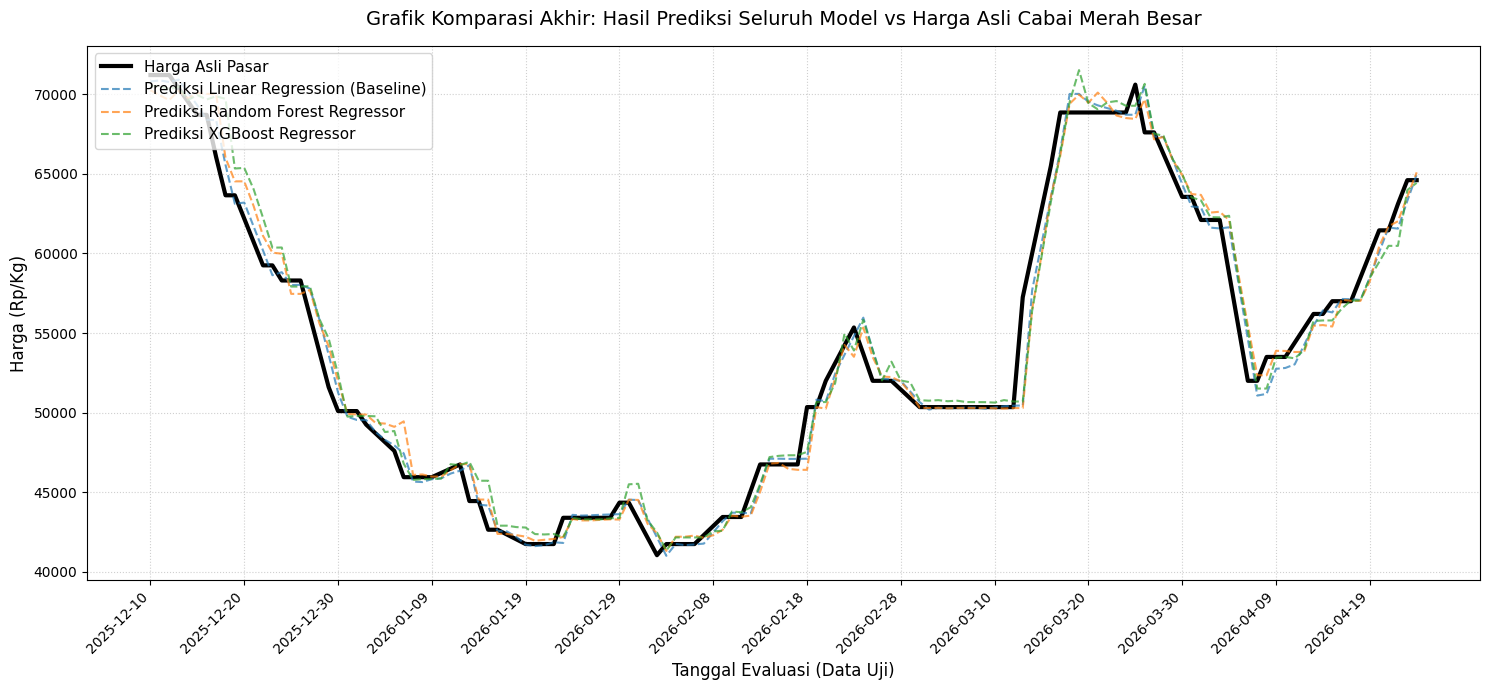

In [12]:
import matplotlib.dates as mdates

test_dates = pd.to_datetime(df['tanggal'].iloc[-len(y_test):])

fig, ax = plt.subplots(figsize=(15, 7))

# 1. Plot Harga Asli
ax.plot(test_dates, y_test.values, label='Harga Asli Pasar', color='black', linewidth=3, linestyle='-')

# 2. Plot Tebakan Model Tabular
for name, model in models.items():
    y_pred = model.predict(X_test)
    ax.plot(test_dates, y_pred, label=f'Prediksi {name}', alpha=0.7, linestyle='--')

ax.set_title('Grafik Komparasi Akhir: Hasil Prediksi Seluruh Model vs Harga Asli Cabai Merah Besar', fontsize=14, pad=15)
ax.set_xlabel('Tanggal Evaluasi (Data Uji)', fontsize=12)
ax.set_ylabel('Harga (Rp/Kg)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

# Atur format tanggal dan jarak tick agar tidak bertumpuk
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xticks(test_dates[::10])
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

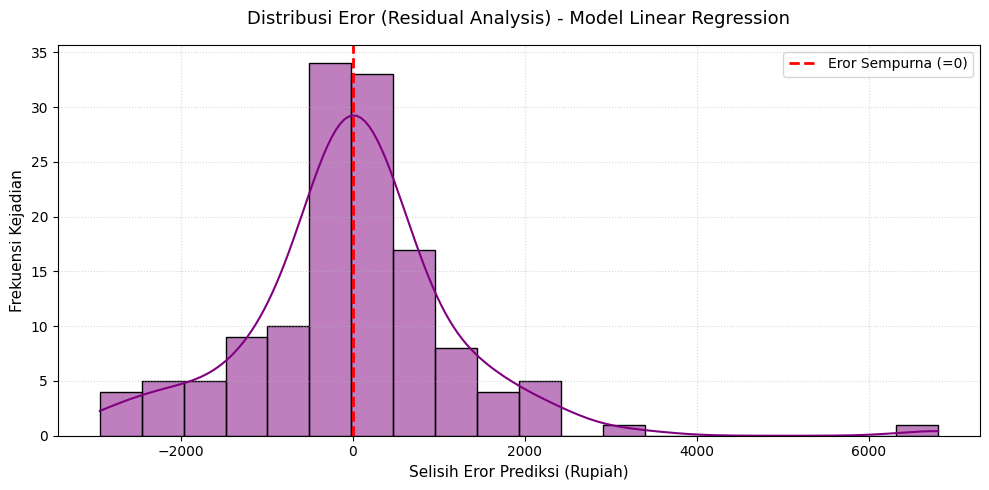

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil model terbaik (Linear Regression) untuk dianalisis sisaannya
best_model = models['Linear Regression (Baseline)']
y_pred_best = best_model.predict(X_test)

# 2. Hitung nilai residual (Error = Aktual - Prediksi)
residuals = y_test - y_pred_best

# 3. Buat visualisasi distribusi residual
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=20, ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Eror Sempurna (=0)')

plt.title('Distribusi Eror (Residual Analysis) - Model Linear Regression', fontsize=13, pad=15)
plt.xlabel('Selisih Eror Prediksi (Rupiah)', fontsize=11)
plt.ylabel('Frekuensi Kejadian', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Penjelasan Tahap Pemodelan
Tahap pemodelan ini dirancang untuk membandingkan performa tiga algoritma dengan karakteristik arsitektur yang berbeda guna menemukan model yang paling presisi dan stabil dalam memprediksi harga cabai harian:

1. **Linear Regression (Baseline):** Model statistik klasik yang memetakan hubungan linear garis lurus antara seluruh fitur prediktor terhadap target harga. Model ini sangat efisien dan kuat dalam menangkap korelasi kuat jangka pendek seperti hubungan harga hari ini dengan harga kemarin (`Cabai_lag_1`).
2. **Random Forest Regressor:** Model berbasis *Ensemble Learning* yang mengombinasikan ratusan pohon keputusan (*Decision Trees*) secara independen (*Bagging*). Model ini unggul dalam menangkap hubungan non-linear dan interaksi kompleks antar variabel cuaca tanpa risiko *overfitting* yang tinggi.
3. **XGBoost Regressor (Extreme Gradient Boosting):** Model tingkat lanjut berbasis pohon keputusan yang dilatih secara bertahap dan korektif (*Boosting*). Model ini sangat sensitif terhadap pola eror dari iterasi sebelumnya dan terbukti sangat kuat untuk pola data tabular yang dinamis.

**Strategi Validasi Data:**
Pembagian dataset dilakukan secara kronologis menggunakan skema *Time Series Split* dengan proporsi **80% Data Latih (Train Set)** untuk proses pembelajaran model dan **20% Data Uji (Test Set)** untuk menguji performa prediksi ke masa depan. Pengacakan data (*shuffle*) dinonaktifkan sepenuhnya demi menjaga struktur urutan waktu asli data runtun waktu.

## Evaluasi Model dan Pengujian (Data Testing)

Tahap pengujian dilakukan menggunakan **20% data terakhir (136 baris data uji)** yang sama sekali belum pernah dilihat oleh model selama proses pelatihan. Evaluasi performa model diukur menggunakan tiga metrik regresi utama, yaitu *Mean Absolute Error* (MAE), *Root Mean Squared Error* (RMSE), dan *R-Squared* ($R^2$ Score).

### 1. Analisis Performa Model
Berdasarkan tabel komparasi di atas, diperoleh metrik sebagai berikut:
* **Linear Regression (Baseline):** Menghasilkan tingkat akurasi tertinggi dengan nilai **MAE sebesar Rp 817,17** dan skor **$R^2$ mencapai 0.9817 (98.17%)**. Hal ini membuktikan bahwa hubungan antara harga cabai hari ini dengan harga satu hari sebelumnya (`Cabai_lag_1`) memiliki pola linearitas jangka pendek yang sangat kuat dan dominan di pasar.
* **Random Forest Regressor:** Menunjukkan performa yang sangat stabil dengan **MAE sebesar Rp 980,48** dan skor **$R^2$ sebesar 0.9744 (97.44%)**.
* **XGBoost Regressor:** Menghasilkan **MAE sebesar Rp 1.089,50** dan skor **$R^2$ sebesar 0.9700 (97.00%)**.

Secara keseluruhan, seluruh model berhasil melampaui batas akurasi ideal ($R^2 > 0.90$). Selisih rata-rata tebakan tebakan model terhadap harga pasar asli (*testing set*) berada di bawah kisaran ~Rp 1.000, yang dikategorikan sebagai tingkat error yang sangat rendah dan presisi untuk prediksi harga komoditas pangan yang fluktuatif.

### 2. Analisis Sisaan (Residual Analysis)
Untuk memvalidasi kelayakan statistik dari model terbaik (Linear Regression), dilakukan analisis *Residual* (selisih antara Harga Asli dengan Harga Prediksi). Model yang ideal harus memiliki sisaan (*error*) yang berdistribusi normal di sekitar angka nol, yang menandakan model tidak memiliki bias sistematis.

In [10]:
import joblib

# Ambil model Linear Regression terbaik dari dictionary models Anda
model_terbaik = models['Linear Regression (Baseline)']

# Simpan model menjadi file fisik bernama 'model_cabai_lr.pkl'
joblib.dump(model_terbaik, 'model_cabai_lr.pkl')
print("Model berhasil disimpan! Silakan unduh file model_cabai_lr.pkl dari folder Colab.")

Model berhasil disimpan! Silakan unduh file model_cabai_lr.pkl dari folder Colab.
